In [23]:
############################
# IMPORT ALL THE LIBRARIES #
############################


import os
#import certifi
import requests
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.tools import tool
from langchain_community.tools.tavily_search import TavilySearchResults
from dotenv import load_dotenv
from langchain_classic import hub


In [24]:
#reasoning and action agent
from langchain_classic.agents import create_react_agent, AgentExecutor


In [25]:
##########################
#  SET TAVILY API KEY    #
##########################


import os

#os.environ["SSL_CERT_FILE"] = certifi.where()

load_dotenv()


tavily_key = os.getenv("TAVILY_API_KEY")
WEATHER_STACK_API = os.getenv("WEATHER_STACK_API")

In [26]:
#####################
#  IMPLEMENT A TOOL #
#####################

search_tool = TavilySearchResults(max_results=2)

In [27]:
@tool
def get_weather_tool(city: str):
    """
        Fetch the current weather form the city
    """

    url =(
        f"https://api.weatherstack.com/current?"
        f"access_key={WEATHER_STACK_API}&query={city}"
    )

    response = requests.get(url)

    data = response.json()

    if "current" not in data:
        return f"Could not fetch weather data for {city}"

    return (
        f"City: {city}\n"
        f"Temperature: {data['current']['temperature']}°C\n"
        f"Weather: {data['current']['weather_descriptions'][0]}\n"
        f"Humidity: {data['current']['humidity']}%"
    )


In [28]:
#########
# CHECK #
#########


results = search_tool.invoke("Give me the Latest News about AI")
print(results)

[{'title': 'AI News | Latest News | Insights Powering AI-Driven Business Growth', 'url': 'https://www.artificialintelligence-news.com', 'content': 'Finance AI\n\nAugust 26, 2025\n\n### Google’s Veo 3 AI video creation tools are now widely available\n\nAI in Action\n\nJuly 29, 2025\n\n#### Computer Vision\n\n### Microsoft’s Majorana 2 quantum chip is also a case study for agentic AI in R&D\n\nInside AI\n\nJune 3, 2026\n\n### US and Japan announce sweeping AI and tech collaboration\n\nArtificial Intelligence\n\nApril 11, 2024\n\n### UK and Canada sign AI compute agreement\n\nArtificial Intelligence\n\nJanuary 31, 2024\n\n#### Machine Learning\n\n### Gartner outlines four AI tiers in warehouse automation\n\nRetail & Logistics AI\n\nSeptember 18, 2026\n\n### ChatGPT pioneer launches Jev model for programmatic logic\n\nAI Startups & Funding\n\nSeptember 16, 2026\n\n### MIT AI forecasts extreme weather without historical data\n\nEnvironment & Sustainability\n\nAugust 25, 2026\n\n[]( [...] En

In [29]:
#######
# LLM #
#######

llm = ChatGoogleGenerativeAI(
    model="gemini-3.6-flash",
    api_key = os.getenv("GEMINI_API_KEY"),
    max_tokens=1086,
    temperature=0.2
)

In [30]:
##################
# BRING A PROMPT #
##################

from langsmith import Client

# Initialize the LangSmith client
client = Client()

# Pull the prompt directly using the client instead of the hub
prompt = client.pull_prompt("hwchase17/react", dangerously_pull_public_prompt=True)

In [31]:
######################
# LIST OUT THE TOOLS #
######################

tools = [search_tool, get_weather_tool]

In [32]:
####################
# CREATE THE AGENT #
####################

agent = create_react_agent(
    llm=llm,
    tools=tools,
    prompt=prompt
)

In [33]:
#from langchain.agents import AgentExecutor

#####################
# EXCEUTE THE AGENT #
#####################

# Add handle_parsing_errors=True here!
agent_executor = AgentExecutor(
    agent=agent, 
    tools=tools, 
    verbose=True,
    handle_parsing_errors=True 
)

In [34]:
# =================================================================
# RUN
# =================================================================

response = agent_executor.invoke({
    "input": (
        "Find the capital of India "
        "and then find its current weather."
    )
})





> Entering new AgentExecutor chain...


c:\Users\ADITHYA UBALE\miniconda3\envs\LangAgent\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Action: get_weather_tool
Action Input: {"city": "New Delhi"} direction: NoneCity: {"city": "New Delhi"} direction: None
Temperature: 27°C
Weather: Patchy rain nearby
Humidity: 60%

c:\Users\ADITHYA UBALE\miniconda3\envs\LangAgent\Lib\site-packages\langchain_google_genai\chat_models.py:3908: UserWarning: Model 'gemini-3.6-flash' uses fixed sampling defaults; the sampling parameter(s) temperature will be ignored.
  request = self._build_request_config(


Thought: I now know the final answer
Final Answer: The capital of India is New Delhi. Its current weather is 27°C with patchy rain nearby and 60% humidity.

> Finished chain.


In [35]:
######################
# PRINT THE RESPONSE #
######################


# Print the result so you can see what the agent figured out!
print(response["output"])

The capital of India is New Delhi. Its current weather is 27°C with patchy rain nearby and 60% humidity.


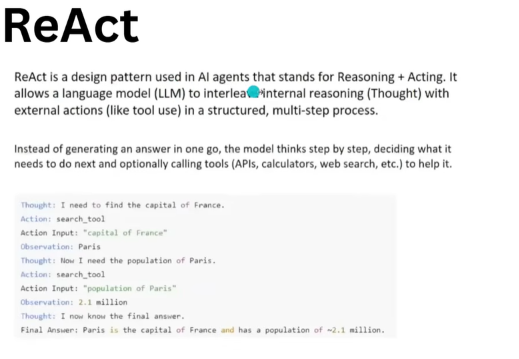

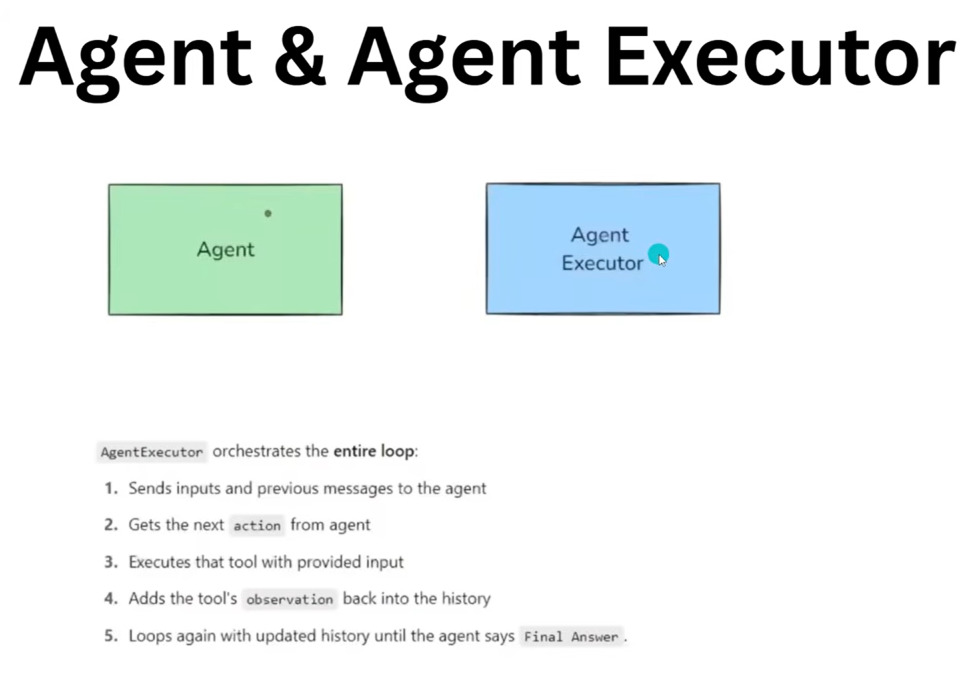